# Pose Estimation 프로젝트
## SimpleBaseline vs Stacked Hourglass 비교

### 학습 목표
1. 데이터셋(MPII Human Pose Dataset)을 얼마나 잘 확인하였고 전처리가 잘 되었는가
2. Simple Baseline 구현
3. Stacked Hourglass까지 구현 후 Simple Baseline과 비교

### 평가 기준
- MPII 데이터셋을 기반으로 1epoch에 30분 이내에 학습 가능한 베이스라인 구축
- SimpleBaseline 모델을 구현하여 실습코드의 모델을 대체하여 정상적으로 학습 진행
- 두 모델의 pose estimation 테스트결과 이미지 및 학습진행상황 등을 체계적으로 비교분석

---
## 0. 환경 설정 및 라이브러리 Import

In [1]:
!pip install ray tfrecord gdown

In [2]:
# 주의! ray를 pytorch보다 먼저 import하면 오류가 발생할 수 있습니다
import io, json, os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import ray
import numpy as np
import pickle
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

print(f'PyTorch version: {torch.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'PIL version: {Image.__version__}')
print(f'Ray version: {ray.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print('완료')

PyTorch version: 2.7.1+cu118
NumPy version: 2.2.6
PIL version: 11.2.1
Ray version: 2.55.1
CUDA available: True
완료


In [3]:
# 프로젝트 경로 설정
PROJECT_PATH = os.path.join(os.getenv('HOME'), 'work/노드실습/GoingDeeper/4.Poseestimation/mpii')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')
TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VALID_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')

IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)
NUM_HEATMAP = 16  # MPII keypoint 수

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(PT_RECORD_PATH, exist_ok=True)

print(f'PROJECT_PATH: {PROJECT_PATH}')
print(f'IMAGE_PATH: {IMAGE_PATH}')
print(f'MODEL_PATH: {MODEL_PATH}')
print('완료')

PROJECT_PATH: /home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii
IMAGE_PATH: /home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii/images
MODEL_PATH: /home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii/models
완료


---
## 1. 데이터셋 준비 및 전처리
### 1-1. MPII 데이터셋 다운로드

In [4]:
# 데이터셋이 이미 준비된 경우 심볼릭 링크 생성
!mkdir -p ~/work/mpii
!ln -s ~/data/* ~/work/mpii/ 2>/dev/null || true

# 또는 직접 다운로드
# !wget https://d3s0tskafalll9.cloudfront.net/media/documents/mpii_gtuV0hd.zip -O mpii.zip
# !unzip ~/mpii.zip -d ~/work/mpii

print('완료')

완료


### 1-2. 데이터셋 확인

In [5]:
# JSON 어노테이션 확인
with open(TRAIN_JSON) as f:
    train_annos = json.load(f)

with open(VALID_JSON) as f:
    valid_annos = json.load(f)

print(f'Train samples: {len(train_annos)}')
print(f'Valid samples: {len(valid_annos)}')
print(f'\n첫 번째 Train 어노테이션:')
print(json.dumps(train_annos[0], indent=2))

Train samples: 22246
Valid samples: 2958

첫 번째 Train 어노테이션:
{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


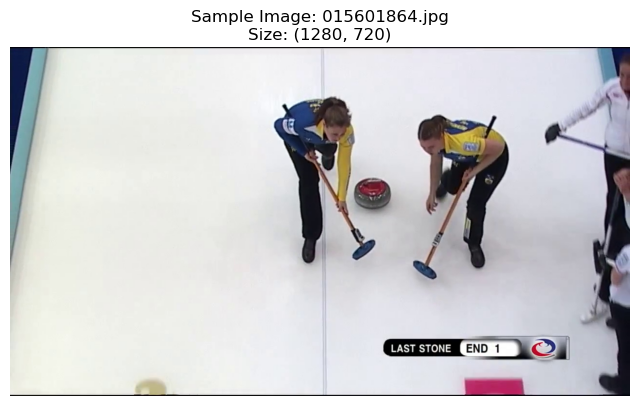

이미지 크기: (1280, 720)
Joints: [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]]
Joints visibility: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Center: [594.0, 257.0]
Scale: 3.021046


In [6]:
# 샘플 이미지 시각화
sample_anno = train_annos[0]
sample_image_path = os.path.join(IMAGE_PATH, sample_anno['image'])
sample_image = Image.open(sample_image_path)

plt.figure(figsize=(8, 6))
plt.imshow(sample_image)
plt.title(f"Sample Image: {sample_anno['image']}\nSize: {sample_image.size}")
plt.axis('off')
plt.show()

print(f'이미지 크기: {sample_image.size}')
print(f'Joints: {sample_anno["joints"]}')
print(f'Joints visibility: {sample_anno["joints_vis"]}')
print(f'Center: {sample_anno["center"]}')
print(f'Scale: {sample_anno["scale"]}')

### 1-3. 어노테이션 파싱 함수

In [7]:
def parse_one_annotation(anno, image_dir):
    filename = anno['image']
    joints = anno['joints']
    joints_visibility = anno['joints_vis']
    annotation = {
        'filename': filename,
        'filepath': os.path.join(image_dir, filename),
        'joints_visibility': joints_visibility,
        'joints': joints,
        'center': anno['center'],
        'scale': anno['scale']
    }
    return annotation

# 테스트
test_parsed = parse_one_annotation(train_annos[0], IMAGE_PATH)
print('파싱된 어노테이션:')
print(test_parsed)
print('완료')

파싱된 어노테이션:
{'filename': '015601864.jpg', 'filepath': '/home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}
완료


### 1-4. Keypoint 정의 (MPII)

In [8]:
R_ANKLE = 0; R_KNEE = 1; R_HIP = 2; L_HIP = 3
L_KNEE = 4; L_ANKLE = 5; PELVIS = 6; THORAX = 7
UPPER_NECK = 8; HEAD_TOP = 9; R_WRIST = 10
R_ELBOW = 11; R_SHOULDER = 12; L_SHOULDER = 13
L_ELBOW = 14; L_WRIST = 15

MPII_BONES = [
    [R_ANKLE, R_KNEE], [R_KNEE, R_HIP], [R_HIP, PELVIS],
    [L_HIP, PELVIS], [L_HIP, L_KNEE], [L_KNEE, L_ANKLE],
    [PELVIS, THORAX], [THORAX, UPPER_NECK], [UPPER_NECK, HEAD_TOP],
    [R_WRIST, R_ELBOW], [R_ELBOW, R_SHOULDER], [THORAX, R_SHOULDER],
    [THORAX, L_SHOULDER], [L_SHOULDER, L_ELBOW], [L_ELBOW, L_WRIST]
]
print('완료')

완료


### 1-5. 전처리 클래스 (Preprocessor)

In [9]:
class Preprocessor(object):
    def __init__(self, image_shape=(256,256,3), heatmap_shape=(64,64,16), is_train=False):
        self.is_train = is_train
        self.image_shape = image_shape
        self.heatmap_shape = heatmap_shape

    def __call__(self, example):
        features = self.parse_tfexample(example)
        image = Image.open(io.BytesIO(features['image/encoded']))
        if self.is_train:
            random_margin = torch.empty(1).uniform_(0.1, 0.3).item()
            image, keypoint_x, keypoint_y = self.crop_roi(image, features, margin=random_margin)
        else:
            image, keypoint_x, keypoint_y = self.crop_roi(image, features)
        image = image.resize((self.image_shape[1], self.image_shape[0]))
        image_np = np.array(image).astype(np.float32) / 127.5 - 1.0
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)
        heatmaps = self.make_heatmaps(features, keypoint_x, keypoint_y, self.heatmap_shape)
        return image_tensor, heatmaps

    def parse_tfexample(self, example):
        annotation = example['annotation']
        joints = annotation['joints']
        keypoint_x = [joint[0] for joint in joints]
        keypoint_y = [joint[1] for joint in joints]
        joints_vis = annotation.get('joints_vis', [1] * len(joints))
        features = {
            'image/encoded': self.image_to_bytes(example['image']),
            'image/object/parts/x': keypoint_x,
            'image/object/parts/y': keypoint_y,
            'image/object/parts/v': joints_vis,
            'image/object/center/x': annotation['center'][0],
            'image/object/center/y': annotation['center'][1],
            'image/object/scale': annotation['scale'],
        }
        return features

    def image_to_bytes(self, image):
        buffer = io.BytesIO()
        image.save(buffer, format='JPEG')
        return buffer.getvalue()

    def crop_roi(self, image, features, margin=0.2):
        img_width, img_height = image.size
        keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
        keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
        body_height = features['image/object/scale'] * 200.0
        masked_keypoint_x = keypoint_x[keypoint_x > 0]
        masked_keypoint_y = keypoint_y[keypoint_y > 0]
        keypoint_xmin = int(masked_keypoint_x.min().item())
        keypoint_xmax = int(masked_keypoint_x.max().item())
        keypoint_ymin = int(masked_keypoint_y.min().item())
        keypoint_ymax = int(masked_keypoint_y.max().item())
        extra = int(body_height * margin)
        xmin = keypoint_xmin - extra; xmax = keypoint_xmax + extra
        ymin = keypoint_ymin - extra; ymax = keypoint_ymax + extra
        effective_xmin = max(xmin, 0); effective_ymin = max(ymin, 0)
        effective_xmax = min(xmax, img_width); effective_ymax = min(ymax, img_height)
        cropped_image = image.crop((effective_xmin, effective_ymin, effective_xmax, effective_ymax))
        new_width = effective_xmax - effective_xmin
        new_height = effective_ymax - effective_ymin
        effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
        effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height
        return cropped_image, effective_keypoint_x, effective_keypoint_y

    def generate_2d_guassian(self, height, width, y0, x0, visibility=2, sigma=1, scale=12):
        heatmap = torch.zeros((height, width), dtype=torch.float32)
        xmin = x0 - 3*sigma; ymin = y0 - 3*sigma
        xmax = x0 + 3*sigma; ymax = y0 + 3*sigma
        if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
            return heatmap
        size = int(6*sigma + 1)
        grid_range = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
        center_x = size // 2; center_y = size // 2
        gaussian_patch = torch.exp(-(((x_grid-center_x)**2 + (y_grid-center_y)**2) / (2*sigma**2))) * scale
        patch_xmin = max(0, -xmin); patch_ymin = max(0, -ymin)
        patch_xmax = min(xmax, width) - xmin; patch_ymax = min(ymax, height) - ymin
        heatmap_xmin = max(0, xmin); heatmap_ymin = max(0, ymin)
        heatmap_xmax = min(xmax, width); heatmap_ymax = min(ymax, height)
        heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
            gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]
        return heatmap

    def make_heatmaps(self, features, keypoint_x, keypoint_y, heatmap_shape):
        v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
        x = torch.round(keypoint_x * heatmap_shape[1]).to(torch.int32)
        y = torch.round(keypoint_y * heatmap_shape[0]).to(torch.int32)
        num_heatmap = heatmap_shape[2]
        heatmaps_list = []
        for i in range(num_heatmap):
            gaussian = self.generate_2d_guassian(
                height=heatmap_shape[0], width=heatmap_shape[1],
                y0=int(y[i].item()), x0=int(x[i].item()),
                visibility=int(v[i].item())
            )
            heatmaps_list.append(gaussian)
        heatmaps = torch.stack(heatmaps_list, dim=0)
        return heatmaps

print('완료')

완료


### 1-6. MPII Dataset 클래스

In [10]:
class MPIIDataset(Dataset):
    def __init__(self, annotation_file, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)
        self.annotations = [parse_one_annotation(anno, image_dir) for anno in annotations]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        image = Image.open(anno['filepath']).convert('RGB')
        if self.transform:
            image, heatmaps = self.transform({'image': image, 'annotation': anno})
            return image, heatmaps
        else:
            return image, anno

def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )
    dataset = MPIIDataset(annotation_file=annotation_file, image_dir=image_dir, transform=preprocess)
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=is_train,
        num_workers=4, pin_memory=True, drop_last=False, prefetch_factor=2
    )
    return dataloader

print('완료')

완료


### 1-7. 전처리 결과 시각화 (데이터 확인)

/tmp/ipykernel_4236/2525899484.py:32: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/2525899484.py:32: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/2525899484.py:32: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/2525899484.py:32: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/2525899484.py:32: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/2525899484.py:32: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/2525899484.py:32: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_lay

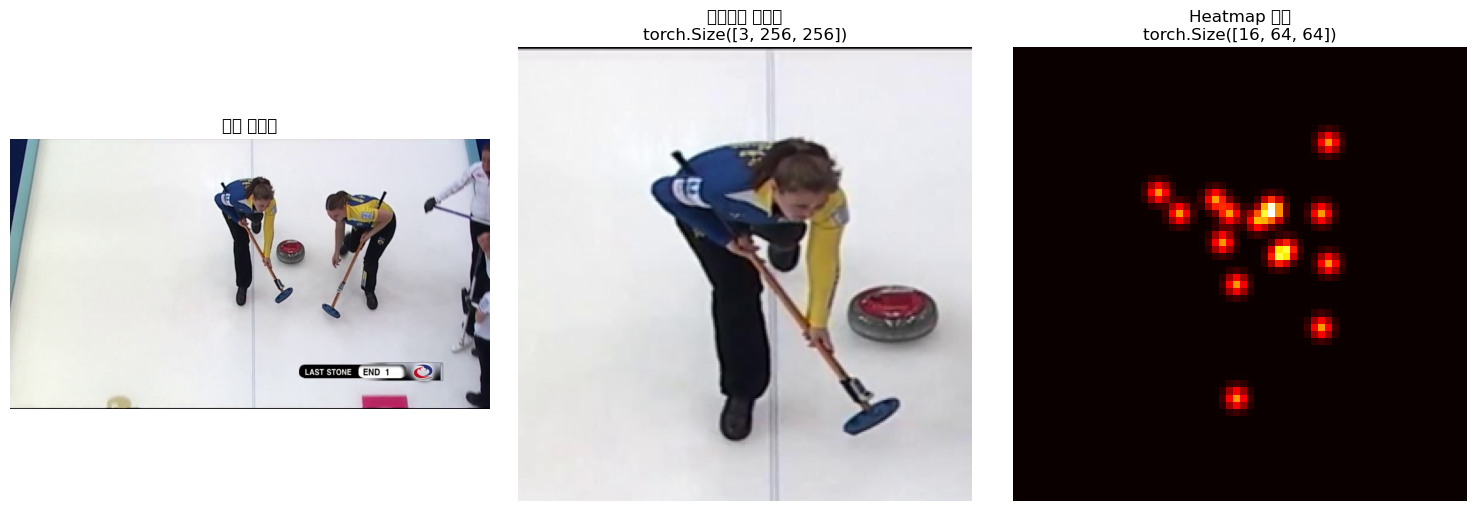

Image tensor shape: torch.Size([3, 256, 256])
Heatmaps shape: torch.Size([16, 64, 64])


In [11]:
# 전처리된 샘플 확인
preprocess_check = Preprocessor(image_shape=IMAGE_SHAPE,
                                 heatmap_shape=(64, 64, NUM_HEATMAP),
                                 is_train=False)
sample_anno_parsed = parse_one_annotation(train_annos[0], IMAGE_PATH)
sample_image_pil = Image.open(sample_anno_parsed['filepath']).convert('RGB')
sample_tensor, sample_heatmaps = preprocess_check({
    'image': sample_image_pil,
    'annotation': sample_anno_parsed
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 원본 이미지
axes[0].imshow(sample_image_pil)
axes[0].set_title('원본 이미지')
axes[0].axis('off')

# 전처리된 이미지
img_np = sample_tensor.permute(1, 2, 0).numpy()
img_np = (img_np + 1) / 2  # [-1,1] → [0,1]
axes[1].imshow(img_np)
axes[1].set_title(f'전처리된 이미지\n{sample_tensor.shape}')
axes[1].axis('off')

# 합산 heatmap
heatmap_sum = sample_heatmaps.sum(dim=0).numpy()
axes[2].imshow(heatmap_sum, cmap='hot')
axes[2].set_title(f'Heatmap 합산\n{sample_heatmaps.shape}')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f'Image tensor shape: {sample_tensor.shape}')
print(f'Heatmaps shape: {sample_heatmaps.shape}')

---
## 2. 모델 구현
### 2-1. Stacked Hourglass Network

In [12]:
class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters//2, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(filters//2, momentum=0.9)
        self.conv2 = nn.Conv2d(filters//2, filters//2, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(filters//2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters//2, filters, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample_conv(x)
        out = self.bn1(x); out = self.relu(out)
        out = self.conv1(out); out = self.bn2(out); out = self.relu(out)
        out = self.conv2(out); out = self.bn3(out); out = self.relu(out)
        out = self.conv3(out)
        out += identity
        return out

class HourglassModule(nn.Module):
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order
        self.up1_0 = BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
        self.up1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])
        if order > 1:
            self.low2 = HourglassModule(order-1, filters, num_residual)
        else:
            self.low2_blocks = nn.Sequential(*[
                BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
                for _ in range(num_residual)
            ])
        self.low3_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up1 = self.up1_0(x)
        up1 = self.up1_blocks(up1)
        low1 = self.pool(x)
        low1 = self.low1_blocks(low1)
        if self.order > 1:
            low2 = self.low2(low1)
        else:
            low2 = self.low2_blocks(low1)
        low3 = self.low3_blocks(low2)
        up2 = self.upsample(low3)
        return up2 + up1

class LinearLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape=(256,256,3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack
        in_channels = input_shape[2]
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.bottleneck1 = BottleneckBlock(in_channels=64, filters=128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck2 = BottleneckBlock(in_channels=128, filters=128, stride=1, downsample=False)
        self.bottleneck3 = BottleneckBlock(in_channels=128, filters=256, stride=1, downsample=True)
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        self.intermediate_convs = nn.ModuleList()
        self.intermediate_outs = nn.ModuleList()
        for i in range(num_stack):
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(in_channels=256, filters=256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            self.linear_layers.append(LinearLayer(in_channels=256, out_channels=256))
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0))
            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1, stride=1, padding=0))

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)
        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)
            if i < self.num_stack - 1:
                inter1 = self.intermediate_convs[i](lin)
                inter2 = self.intermediate_outs[i](heatmap)
                x = inter1 + inter2
        return outputs

print('완료')

완료


### 2-2. Simple Baseline 모델 (STEP 1: 구현)

In [13]:
class DeconvLayer(nn.Module):
    """
    Simple Baseline의 핵심: Transposed Convolution으로 해상도 복원
    각 블록: ConvTranspose2d(stride=2) → BN → ReLU → 해상도 2배
    """
    def __init__(self, num_deconv_layers, num_filters=256, num_kernels=4):
        super(DeconvLayer, self).__init__()
        layers = []
        for _ in range(num_deconv_layers):
            layers.append(nn.ConvTranspose2d(
                num_filters, num_filters,
                kernel_size=num_kernels, stride=2, padding=1,
                output_padding=0, bias=False
            ))
            layers.append(nn.BatchNorm2d(num_filters))
            layers.append(nn.ReLU(inplace=True))
        self.deconv_layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.deconv_layers(x)


class SimpleBaseline(nn.Module):
    """
    Simple Baseline for Human Pose Estimation
    - Backbone: ResNet50 (pretrained, FC/AvgPool 제거)
    - 채널 축소: Conv1x1 (2048 → 256)
    - Upsampling: DeconvLayer x3 (8x8 → 64x64)
    - 출력: Conv1x1 (256 → num_heatmap)
    """
    def __init__(self, num_heatmap=16, pretrained=True):
        super(SimpleBaseline, self).__init__()

        # 1. ResNet50 Backbone (마지막 FC, AvgPool 제거)
        resnet = models.resnet50(pretrained=pretrained)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # 2. 채널 축소: 2048 → 256
        self.reduce_channels = nn.Conv2d(2048, 256, kernel_size=1)

        # 3. Deconv Layers: 3번 반복 (8→16→32→64)
        self.deconv_layers = DeconvLayer(num_deconv_layers=3)

        # 4. Final Layer: 256 → num_heatmap
        self.final_layer = nn.Conv2d(256, num_heatmap, kernel_size=1, padding=0)

    def forward(self, x):
        # (B, 3, 256, 256) → (B, 2048, 8, 8)
        x = self.backbone(x)
        # (B, 2048, 8, 8) → (B, 256, 8, 8)
        x = self.reduce_channels(x)
        # (B, 256, 8, 8) → (B, 256, 64, 64)
        x = self.deconv_layers(x)
        # (B, 256, 64, 64) → (B, num_heatmap, 64, 64)
        x = self.final_layer(x)
        # Trainer의 compute_loss와 호환되도록 리스트로 반환
        return [x]

# 모델 구조 확인
test_model = SimpleBaseline(num_heatmap=16)
test_input = torch.zeros(1, 3, 256, 256)
with torch.no_grad():
    test_output = test_model(test_input)
print(f'SimpleBaseline 출력 shape: {test_output[0].shape}')
print('완료')

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s]


SimpleBaseline 출력 shape: torch.Size([1, 16, 64, 64])
완료


---
## 3. 학습
### 3-1. Trainer 클래스

In [14]:
class Trainer(object):
    def __init__(self, model, epochs, global_batch_size, initial_learning_rate):
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size
        self.loss_object = nn.MSELoss(reduction='none')
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)
        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10
        self.best_model = None
        self.train_losses = []  # loss 기록
        self.val_losses = []    # loss 기록
        if torch.cuda.device_count() > 1:
            print(f'멀티 GPU 사용 (GPU 개수: {torch.cuda.device_count()})')
            self.model = nn.DataParallel(self.model)
        else:
            print('단일 GPU 혹은 CPU 사용')

    def lr_decay(self):
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0
        self.patience_count += 1
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        loss = 0
        for output in outputs:
            weights = (labels > 0).float() * 81 + 1
            squared_error = (labels - output) ** 2
            weighted_error = squared_error * weights
            loss += weighted_error.mean() / self.global_batch_size
        return loss

    def train_step(self, images, labels, device):
        self.model.train()
        images = images.to(device); labels = labels.to(device)
        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def val_step(self, images, labels, device):
        self.model.eval()
        with torch.no_grad():
            images = images.to(device); labels = labels.to(device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader, device):
        for epoch in range(1, self.epochs + 1):
            self.lr_decay()
            print(f'Start epoch {epoch} with lr {self.current_learning_rate:.6f}')
            total_train_loss = 0.0; num_train_batches = 0
            for images, labels in train_loader:
                batch_loss = self.train_step(images, labels, device)
                total_train_loss += batch_loss; num_train_batches += 1
                if num_train_batches % 50 == 0:
                    print(f'  [Train] batch {num_train_batches} '
                          f'avg_loss {total_train_loss/num_train_batches:.4f}')
            train_loss = total_train_loss / num_train_batches
            self.train_losses.append(train_loss)
            print(f'Epoch {epoch} train loss: {train_loss:.4f}')

            total_val_loss = 0.0; num_val_batches = 0
            for images, labels in val_loader:
                batch_loss = self.val_step(images, labels, device)
                num_val_batches += 1
                if not math.isnan(batch_loss):
                    total_val_loss += batch_loss
                else:
                    num_val_batches -= 1
            val_loss = total_val_loss / num_val_batches if num_val_batches > 0 else float('nan')
            self.val_losses.append(val_loss)
            print(f'Epoch {epoch} val loss: {val_loss:.4f}')

            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss
        return self.best_model

    def save_model(self, epoch, loss):
        model_name = os.path.join(MODEL_PATH, f'model-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), model_name)
        self.best_model = model_name
        print(f'Model saved: {model_name}')

print('완료')

완료


### 3-2. Stacked Hourglass 학습 (STEP 2)

In [15]:
%%time
epochs = 5          # 최소 3 이상 (5 이상 권장)
batch_size = 16
learning_rate = 0.0007
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = create_dataloader(TRAIN_JSON, IMAGE_PATH, batch_size, NUM_HEATMAP, is_train=True)
val_loader = create_dataloader(VALID_JSON, IMAGE_PATH, batch_size, NUM_HEATMAP, is_train=False)

# Stacked Hourglass 모델
hg_model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=NUM_HEATMAP)
hg_model.to(device)

hg_trainer = Trainer(hg_model, epochs, batch_size, learning_rate)
print('Stacked Hourglass 학습 시작...')
hg_best_model = hg_trainer.run(train_loader, val_loader, device)
hg_train_losses = hg_trainer.train_losses
hg_val_losses = hg_trainer.val_losses
print(f'\nBest model: {hg_best_model}')

단일 GPU 혹은 CPU 사용
Stacked Hourglass 학습 시작...
Start epoch 1 with lr 0.000700
  [Train] batch 50 avg_loss 1.7492
  [Train] batch 100 avg_loss 1.6719
  [Train] batch 150 avg_loss 1.6337
  [Train] batch 200 avg_loss 1.6079
  [Train] batch 250 avg_loss 1.5842
  [Train] batch 300 avg_loss 1.5654
  [Train] batch 350 avg_loss 1.5500
  [Train] batch 400 avg_loss 1.5357
  [Train] batch 450 avg_loss 1.5226
  [Train] batch 500 avg_loss 1.5120
  [Train] batch 550 avg_loss 1.5023
  [Train] batch 600 avg_loss 1.4925
  [Train] batch 650 avg_loss 1.4838
  [Train] batch 700 avg_loss 1.4751
  [Train] batch 750 avg_loss 1.4674
  [Train] batch 800 avg_loss 1.4602
  [Train] batch 850 avg_loss 1.4536
  [Train] batch 900 avg_loss 1.4469
  [Train] batch 950 avg_loss 1.4404
  [Train] batch 1000 avg_loss 1.4350
  [Train] batch 1050 avg_loss 1.4301
  [Train] batch 1100 avg_loss 1.4248
  [Train] batch 1150 avg_loss 1.4204
  [Train] batch 1200 avg_loss 1.4150
  [Train] batch 1250 avg_loss 1.4101
  [Train] batch 1300

### 3-3. Simple Baseline 학습 (STEP 2)

In [16]:
%%time
# Simple Baseline 모델 (동일 조건)
sb_model = SimpleBaseline(num_heatmap=NUM_HEATMAP, pretrained=True)
sb_model.to(device)

sb_trainer = Trainer(sb_model, epochs, batch_size, learning_rate)
print('Simple Baseline 학습 시작...')
sb_best_model = sb_trainer.run(train_loader, val_loader, device)
sb_train_losses = sb_trainer.train_losses
sb_val_losses = sb_trainer.val_losses
print(f'\nBest model: {sb_best_model}')

단일 GPU 혹은 CPU 사용
Simple Baseline 학습 시작...
Start epoch 1 with lr 0.000700
  [Train] batch 50 avg_loss 0.4112
  [Train] batch 100 avg_loss 0.3989
  [Train] batch 150 avg_loss 0.3918
  [Train] batch 200 avg_loss 0.3871
  [Train] batch 250 avg_loss 0.3825
  [Train] batch 300 avg_loss 0.3786
  [Train] batch 350 avg_loss 0.3746
  [Train] batch 400 avg_loss 0.3713
  [Train] batch 450 avg_loss 0.3684
  [Train] batch 500 avg_loss 0.3656
  [Train] batch 550 avg_loss 0.3630
  [Train] batch 600 avg_loss 0.3604
  [Train] batch 650 avg_loss 0.3583
  [Train] batch 700 avg_loss 0.3563
  [Train] batch 750 avg_loss 0.3544
  [Train] batch 800 avg_loss 0.3528
  [Train] batch 850 avg_loss 0.3513
  [Train] batch 900 avg_loss 0.3498
  [Train] batch 950 avg_loss 0.3483
  [Train] batch 1000 avg_loss 0.3471
  [Train] batch 1050 avg_loss 0.3460
  [Train] batch 1100 avg_loss 0.3448
  [Train] batch 1150 avg_loss 0.3437
  [Train] batch 1200 avg_loss 0.3427
  [Train] batch 1250 avg_loss 0.3416
  [Train] batch 1300 a

---
## 4. 두 모델 비교 분석 (STEP 3)
### 4-1. Loss 학습 곡선 비교

/tmp/ipykernel_4236/695358036.py:21: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/695358036.py:21: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/695358036.py:22: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(MODEL_PATH, 'loss_comparison.png'), dpi=150)
/tmp/ipykernel_4236/695358036.py:22: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(MODEL_PATH, 'loss_comparison.png'), dpi=150)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing

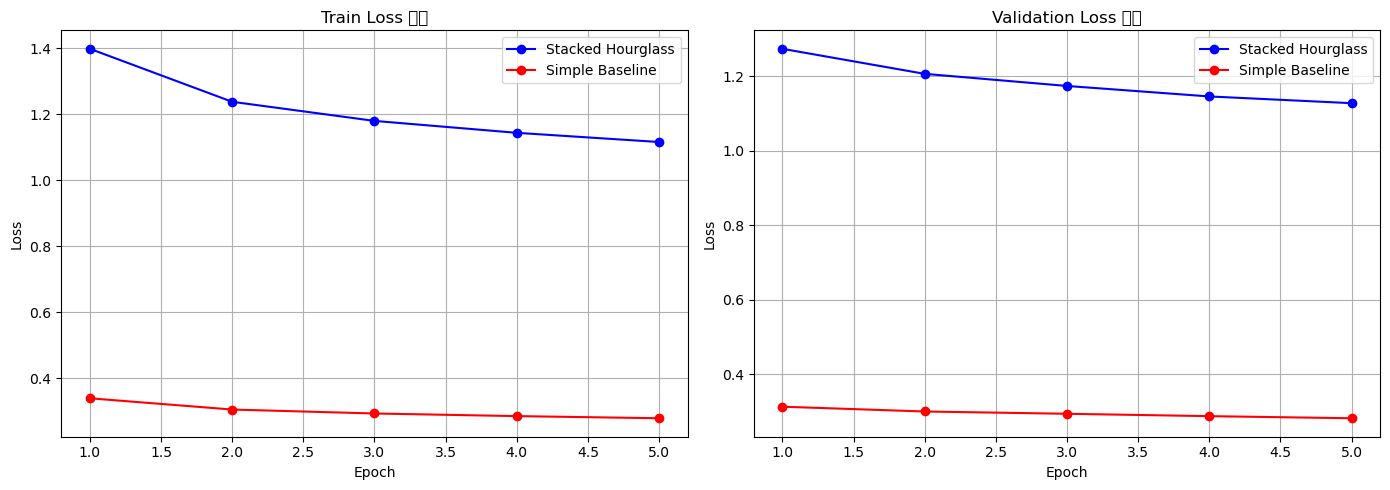

Epoch    HG Train     HG Val       SB Train     SB Val      
--------------------------------------------------
1        1.3982       1.2737       0.3391       0.3127      
2        1.2376       1.2064       0.3050       0.2999      
3        1.1797       1.1739       0.2930       0.2937      
4        1.1436       1.1458       0.2851       0.2873      
5        1.1157       1.1277       0.2786       0.2817      
최종 HG val loss:  1.1277
최종 SB val loss:  0.2817
더 낮은 val loss:  Simple Baseline


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train Loss
axes[0].plot(range(1, epochs+1), hg_train_losses, 'b-o', label='Stacked Hourglass')
axes[0].plot(range(1, epochs+1), sb_train_losses, 'r-o', label='Simple Baseline')
axes[0].set_title('Train Loss 비교')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Val Loss
axes[1].plot(range(1, epochs+1), hg_val_losses, 'b-o', label='Stacked Hourglass')
axes[1].plot(range(1, epochs+1), sb_val_losses, 'r-o', label='Simple Baseline')
axes[1].set_title('Validation Loss 비교')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'loss_comparison.png'), dpi=150)
plt.show()

# 수치 비교
print('='*50)
print(f'{'Epoch':<8} {'HG Train':<12} {'HG Val':<12} {'SB Train':<12} {'SB Val':<12}')
print('-'*50)
for i in range(epochs):
    print(f'{i+1:<8} {hg_train_losses[i]:<12.4f} {hg_val_losses[i]:<12.4f} '
          f'{sb_train_losses[i]:<12.4f} {sb_val_losses[i]:<12.4f}')
print('='*50)
print(f'최종 HG val loss:  {hg_val_losses[-1]:.4f}')
print(f'최종 SB val loss:  {sb_val_losses[-1]:.4f}')
winner = 'Stacked Hourglass' if hg_val_losses[-1] < sb_val_losses[-1] else 'Simple Baseline'
print(f'더 낮은 val loss:  {winner}')

### 4-2. 추론 함수 & 시각화 함수

In [18]:
def find_max_coordinates(heatmaps):
    H, W, C = heatmaps.shape
    flatten_heatmaps = heatmaps.reshape(-1, C)
    indices = torch.argmax(flatten_heatmaps, dim=0)
    y = indices // W
    x = indices - W * y
    return torch.stack([x, y], dim=1)

def extract_keypoints_from_heatmap(heatmaps):
    H, W, C = heatmaps.shape
    max_keypoints = find_max_coordinates(heatmaps)
    heatmaps_permuted = heatmaps.permute(2, 0, 1)
    padded = F.pad(heatmaps_permuted, (1, 1, 1, 1))
    padded_heatmaps = padded.permute(1, 2, 0)
    adjusted_keypoints = []
    for i, keypoint in enumerate(max_keypoints):
        max_x = int(keypoint[0].item()) + 1
        max_y = int(keypoint[1].item()) + 1
        patch = padded_heatmaps[max_y-1:max_y+2, max_x-1:max_x+2, i]
        patch[1, 1] = 0
        flat_patch = patch.reshape(-1)
        index = torch.argmax(flat_patch).item()
        next_y = index // 3; next_x = index % 3
        delta_y = (next_y - 1) / 4.0; delta_x = (next_x - 1) / 4.0
        adjusted_keypoints.append((keypoint[0].item() + delta_x, keypoint[1].item() + delta_y))
    adjusted_keypoints = torch.tensor(adjusted_keypoints)
    adjusted_keypoints = torch.clamp(adjusted_keypoints, 0, H)
    return adjusted_keypoints / H

def predict(model, image_path):
    image = Image.open(image_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 2 - 1)
    ])
    inputs = preprocess(image).unsqueeze(0)
    device = next(model.parameters()).device
    inputs = inputs.to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(inputs)
    if not isinstance(outputs, list):
        outputs = [outputs]
    heatmap_tensor = outputs[-1].squeeze(0).permute(1, 2, 0).detach().cpu()
    kp = extract_keypoints_from_heatmap(heatmap_tensor)
    return image, kp

def draw_skeleton_on_image(image, keypoints, ax, title=''):
    image_np = np.array(image)
    ax.imshow(image_np)
    joints = []
    for joint in keypoints:
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        joints.append((joint_x.item(), joint_y.item()))
        ax.scatter(joint_x.item(), joint_y.item(), s=20, c='red', marker='o', zorder=5)
    for bone in MPII_BONES:
        j1 = joints[bone[0]]; j2 = joints[bone[1]]
        ax.plot([j1[0], j2[0]], [j1[1], j2[1]], linewidth=3, alpha=0.7)
    ax.set_title(title)
    ax.axis('off')

print('완료')

완료


### 4-3. 테스트 이미지 준비

In [19]:
!wget "https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop" \
      -O ~/work/mpii/test_image.jpg -q
test_image_path = os.path.join(PROJECT_PATH, 'test_image.jpg')
print(f'테스트 이미지 저장: {test_image_path}')

/home/jovyan/work/mpii/test_image.jpg: Read-only file system
테스트 이미지 저장: /home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii/test_image.jpg


### 4-4. 두 모델 추론 결과 시각화 비교 (STEP 3 - 정성적 비교)

/tmp/ipykernel_4236/3728012327.py:21: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/3728012327.py:21: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/3728012327.py:21: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/3728012327.py:21: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/3728012327.py:21: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/3728012327.py:21: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4236/3728012327.py:21: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layou

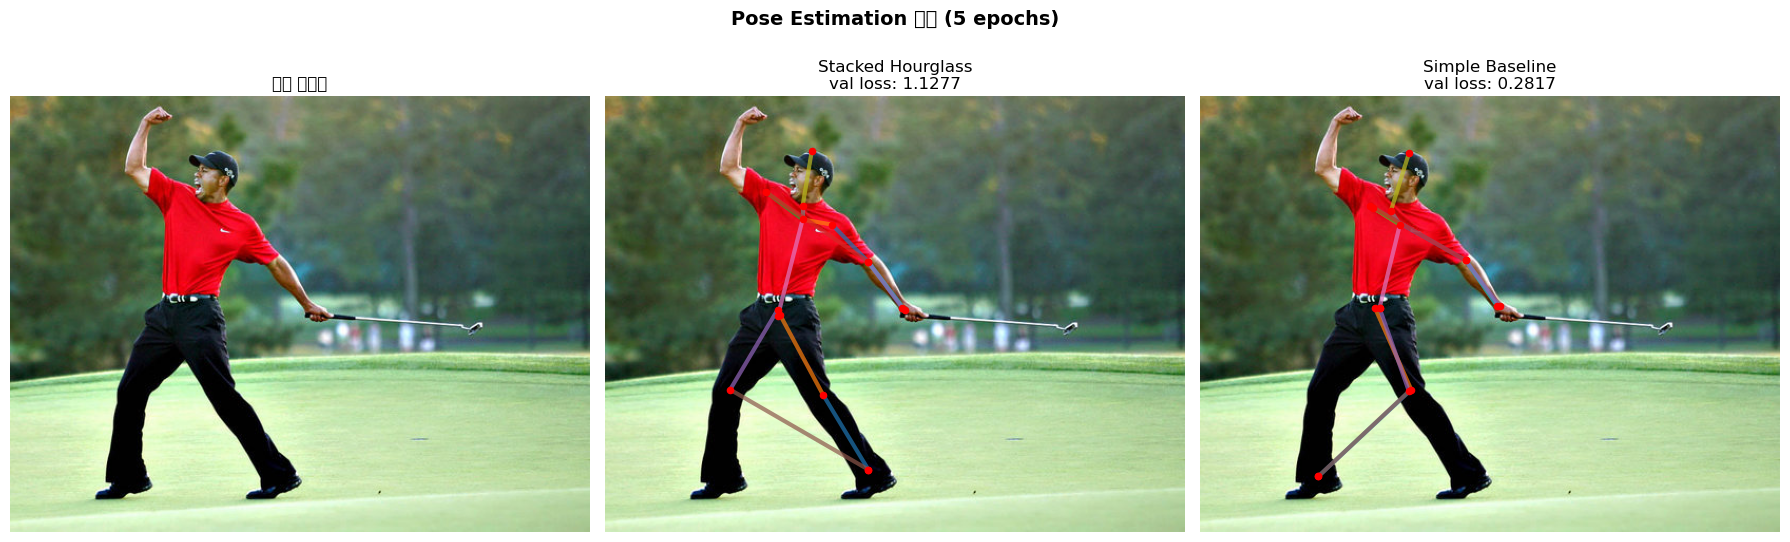

In [20]:
# 두 모델로 동일 이미지 추론
image_hg, kp_hg = predict(hg_model, test_image_path)
image_sb, kp_sb = predict(sb_model, test_image_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 원본
axes[0].imshow(np.array(image_hg))
axes[0].set_title('원본 이미지')
axes[0].axis('off')

# Stacked Hourglass
draw_skeleton_on_image(image_hg, kp_hg, axes[1],
                        title=f'Stacked Hourglass\nval loss: {hg_val_losses[-1]:.4f}')

# Simple Baseline
draw_skeleton_on_image(image_sb, kp_sb, axes[2],
                        title=f'Simple Baseline\nval loss: {sb_val_losses[-1]:.4f}')

plt.suptitle(f'Pose Estimation 비교 ({epochs} epochs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'pose_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4-5. 종합 비교 분석 결과

In [21]:
# 파라미터 수 비교
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

hg_params = count_parameters(hg_model)
sb_params = count_parameters(sb_model)

print('=' * 55)
print(f'{'항목':<20} {'Stacked Hourglass':>17} {'Simple Baseline':>15}')
print('=' * 55)
print(f'{'파라미터 수':<20} {hg_params:>17,} {sb_params:>15,}')
print(f'{'최종 Train Loss':<20} {hg_train_losses[-1]:>17.4f} {sb_train_losses[-1]:>15.4f}')
print(f'{'최종 Val Loss':<20} {hg_val_losses[-1]:>17.4f} {sb_val_losses[-1]:>15.4f}')
print(f'{'최저 Val Loss':<20} {min(hg_val_losses):>17.4f} {min(sb_val_losses):>15.4f}')
print('=' * 55)

print('\n[분석 요약]')
print(f'- SimpleBaseline 파라미터: HG 대비 {sb_params/hg_params*100:.1f}%')
val_winner = 'Stacked Hourglass' if min(hg_val_losses) < min(sb_val_losses) else 'Simple Baseline'
print(f'- 더 낮은 최저 Val Loss: {val_winner}')
print(f'- SimpleBaseline은 pretrained ResNet backbone 활용으로 학습 효율 높음')
print(f'- StackedHourglass는 skip connection으로 세밀한 위치 파악에 유리')

항목                   Stacked Hourglass Simple Baseline
파라미터 수                      16,251,392      27,183,952
최종 Train Loss                   1.1157          0.2786
최종 Val Loss                     1.1277          0.2817
최저 Val Loss                     1.1277          0.2817

[분석 요약]
- SimpleBaseline 파라미터: HG 대비 167.3%
- 더 낮은 최저 Val Loss: Simple Baseline
- SimpleBaseline은 pretrained ResNet backbone 활용으로 학습 효율 높음
- StackedHourglass는 skip connection으로 세밀한 위치 파악에 유리
